In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import statsmodels.api as sm

### 資料探勘與觀察
觀察是否有出現與美國市場相同或相異的性質，先針對本益比、股利率以及成長率觀察

台灣市場數據
1. TAIEX大盤指數：透過Yfinance
2. Turnover, PE, Dividend, P/B 則是根據台灣證券交易所 - 市場交易月報 - 證券市場統計概要與市場總市值、投資報酬率、本益比、殖利率一覽表
3. 經濟成長率：臺北產經知識網，抓取年化數據 (與去年對比)

In [3]:
df = pd.read_csv("df.csv")
df.set_index('Date', inplace=True) # 將 Date 欄位設為 Index
df.index = pd.to_datetime(df.index) # 確保 Index 轉換為 Datetime 格式
df

,TAIEX,Turnover,PE,Dividend,P/B,growth,growth_q
Date,,,,,,,
2005-01-31,5994.202148,9.89,12.40,4.44,1.680000,5.38,1.83
2005-02-28,6207.801270,8.31,12.91,4.39,1.740000,5.38,1.83
2005-03-31,6005.852051,12.42,12.59,5.23,1.690000,5.38,1.83
2005-04-30,5818.043457,8.53,14.22,5.62,1.550174,5.38,6.97
2005-05-31,6011.532227,9.12,14.68,5.49,1.600000,5.38,6.97
...,...,...,...,...,...,...,...
2025-07-31,23542.519530,9.75,18.89,2.90,2.490000,4.45,7.02
2025-08-31,24233.099610,10.99,20.05,2.82,2.740000,4.45,7.02
2025-09-30,25820.539060,11.75,21.37,2.66,2.920000,4.45,7.02


#### 觀察台灣市場數據特色

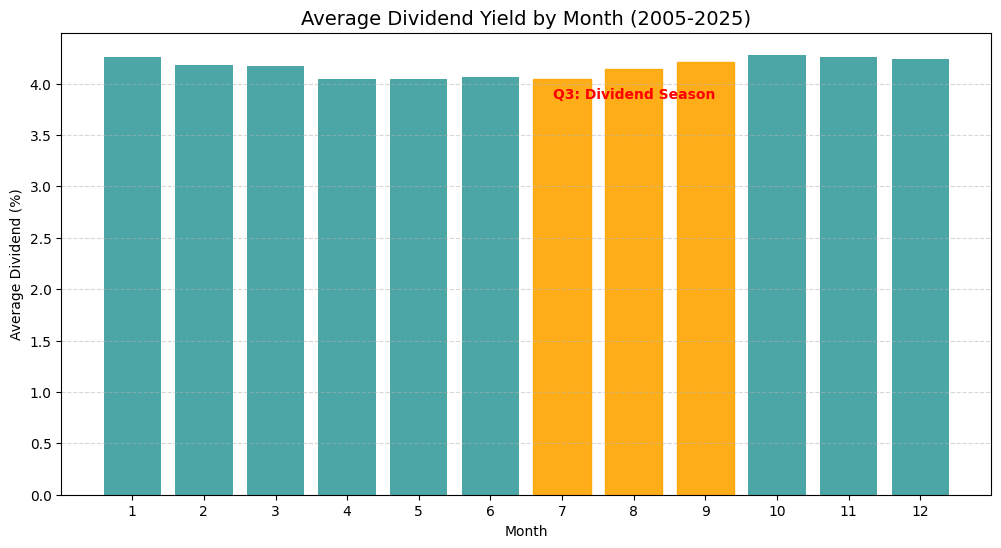

--- 各季度平均殖利率統計 ---
Quarter
1    4.204603
2    4.050716
3    4.128263
4    4.259014
Name: Dividend, dtype: float64


In [4]:
# 1. 提取月份與季度資訊
df['Month'] = df.index.month
df['Quarter'] = df.index.quarter

# 2. 計算每個月的平均殖利率
monthly_avg_div = df.groupby('Month')['Dividend'].mean()

# 3. 計算每個季度的平均殖利率
quarterly_avg_div = df.groupby('Quarter')['Dividend'].mean()

# 4. 繪製月份分析圖表
plt.figure(figsize=(12, 6))
bars = plt.bar(monthly_avg_div.index, monthly_avg_div.values, color='teal', alpha=0.7)

# 標註 Q3 的顏色（7, 8, 9月）讓它更明顯
for i in [6, 7, 8]: # Index 是從 0 開始，所以 7, 8, 9月是 index 6, 7, 8
    bars[i].set_color('orange')
    bars[i].set_alpha(0.9)

plt.title('Average Dividend Yield by Month (2005-2025)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Average Dividend (%)')
plt.xticks(range(1, 13))
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 加入 Q3 的標註
plt.text(8, max(monthly_avg_div)*0.9, 'Q3: Dividend Season', color='red', fontweight='bold', ha='center')

plt.show()

# 5. 印出季度統計數據
print("--- 各季度平均殖利率統計 ---")
print(quarterly_avg_div)

可以發現其實從現有數據來看，台股 Q3 股利發放潮不明顯

#### 初步觀察以及 SOP 建構

In [5]:
# 1. 變數轉化 
df['r'] = np.log(df['TAIEX'] / df['TAIEX'].shift(1))
df['gm'] = np.log(df['PE'] / df['PE'].shift(1))
#df['ge'] = (df['growth_q'] / 100) / 12  # 轉為月增長率
df['ge'] = np.log(1 + df['growth'] / 100) / 12
df['dp'] = (df['Dividend'] / 100) / 12 # 轉為月股息收益

# 2. 計算 Univariate Statistics
stats = pd.DataFrame()
for col in ['gm', 'ge', 'dp', 'r']:
    s = df[col].describe()
    stats[col] = [s['mean'], s['50%'], s['std'], s['min'], s['max'], df[col].skew(), df[col].kurt(), df[col].autocorr()]

stats.index = ['Mean', 'Median', 'Std Dev', 'Min', 'Max', 'Skewness', 'Kurtosis', 'AR(1)']
print("--- Panel A: Univariate Statistics ---")
print(stats.round(4))

# 3. 計算 Correlations
corr_matrix = df[['gm', 'ge', 'dp', 'r']].corr()
print("\n--- Panel B: Correlations ---")
print(corr_matrix.round(2))

--- Panel A: Univariate Statistics ---
               gm      ge      dp       r
Mean       0.0023  0.0030  0.0035  0.0061
Median     0.0069  0.0028  0.0034  0.0100
Std Dev    0.1360  0.0020  0.0010  0.0518
Min       -0.9703 -0.0014  0.0020 -0.2086
Max        1.1020  0.0081  0.0088  0.1398
Skewness   0.1031  0.4040  2.2994 -0.6098
Kurtosis  32.0972  0.7956  9.3530  1.8617
AR(1)      0.3836  0.9052  0.9419  0.0785

--- Panel B: Correlations ---
      gm    ge    dp     r
gm  1.00 -0.33 -0.01  0.42
ge -0.33  1.00 -0.26  0.02
dp -0.01 -0.26  1.00 -0.30
r   0.42  0.02 -0.30  1.00


In [6]:
df_annual = pd.DataFrame()
df_annual['r']  = df['r'].resample('YE').sum()
df_annual['gm'] = df['gm'].resample('YE').sum()
df_annual['ge'] = df['ge'].resample('YE').sum()
df_annual['dp'] = df['dp'].resample('YE').sum()

# 4. 定義統計函式：計算 Table 1 Panel A & B
def generate_annual_tables(data):
    # --- Panel A: Univariate Statistics ---
    stats = pd.DataFrame()
    for col in ['gm', 'ge', 'dp', 'r']:
        c = data[col].dropna()
        stats[col] = [
            c.mean(), 
            c.median(), 
            c.std(), 
            c.min(), 
            c.max(), 
            c.skew(), 
            c.kurtosis(), 
            c.autocorr(lag=1)
        ]
    stats.index = ['Mean', 'Median', 'Std Dev', 'Min', 'Max', 'Skewness', 'Kurtosis', 'AR(1)']
    
    # --- Panel B: Correlations ---
    corr = data[['gm', 'ge', 'dp', 'r']].corr()
    
    return stats, corr

# 5. 執行並輸出結果
stats_table, corr_table = generate_annual_tables(df_annual)

print("--- [Annual Frequency] Panel A: Univariate Statistics ---")
print(stats_table.round(4))

print("\n--- [Annual Frequency] Panel B: Correlations ---")
print(corr_table.round(2))

--- [Annual Frequency] Panel A: Univariate Statistics ---
              gm      ge      dp       r
Mean      0.0276  0.0356  0.0414  0.0728
Median   -0.0176  0.0336  0.0416  0.1042
Std Dev   0.7524  0.0243  0.0090  0.2387
Min      -1.9303 -0.0162  0.0259 -0.6167
Max       2.4230  0.0976  0.0653  0.5785
Skewness  0.8308  0.4541  0.4876 -1.0276
Kurtosis  6.6120  1.3870  1.5620  3.0844
AR(1)    -0.5231 -0.1570  0.3149 -0.3572

--- [Annual Frequency] Panel B: Correlations ---
      gm    ge    dp     r
gm  1.00 -0.72  0.15  0.51
ge -0.72  1.00 -0.35  0.04
dp  0.15 -0.35  1.00 -0.54
r   0.51  0.04 -0.54  1.00


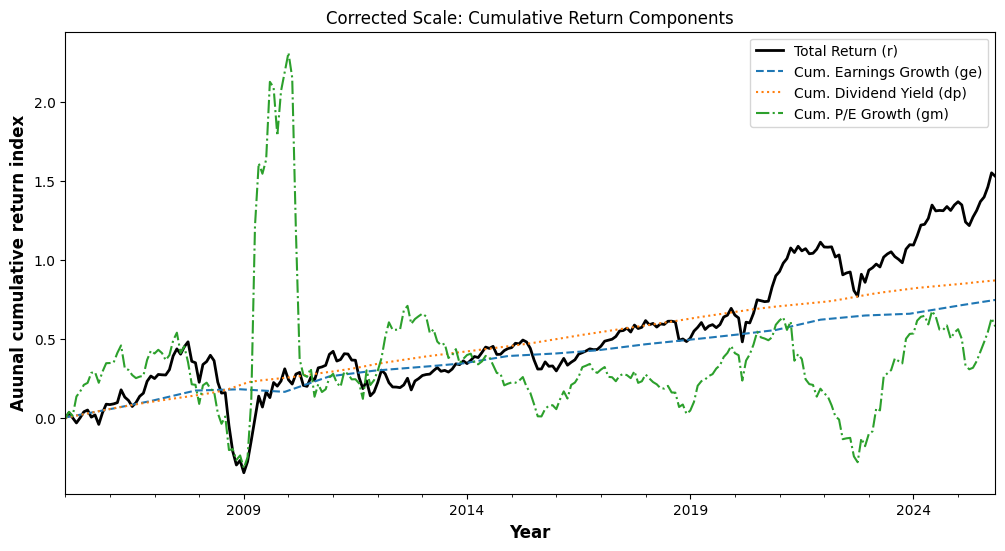

In [7]:
# 3. 繪圖
plt.figure(figsize=(12, 6))

# 使用累加確保尺度一致
(df['r'].fillna(0).cumsum()).plot(label='Total Return (r)', color='black', linewidth=2)
(df['ge'].fillna(0).cumsum()).plot(label='Cum. Earnings Growth (ge)', linestyle='--')
(df['dp'].fillna(0).cumsum()).plot(label='Cum. Dividend Yield (dp)', linestyle=':')
(df['gm'].fillna(0).cumsum()).plot(label='Cum. P/E Growth (gm)', linestyle='-.')

plt.ylabel('Auunal cumulative return index', fontsize=12, fontweight='bold')
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.title('Corrected Scale: Cumulative Return Components')
plt.legend()
plt.show()

小結論：
1. 本益比成長 (gm) 標準差高達0.136，遠高於ge、dp，也解釋了其波動最為劇烈
2. 短期波動主要受本益比變動影響
3. 使用月頻率之下，

### 觀察 SOP 是否勝過傳統預測回歸以及歷史平均方法

In [8]:
# 初始化預測 (觀測期間 2010-01-31 到 2025-11-30)
# 2005~2010 為預留時間給 ge (5年的動態窗格)
start_date = '2010-01-31'
df_test = df[df.index >= start_date].copy()
forecast_results = pd.DataFrame(index=df_test.index) # 存放對下一期報酬率的預測

# 逐期 Expanding window 估計+預測
for i in range(len(df_test)):
    # 使用 1~t-1期的數據來預測 t 期
    current_date = df_test.index[i]
    train_data = df[df.index < current_date]
    
    # 基準：歷史平均 (HM)
    forecast_results.loc[current_date, 'HM'] = train_data['r'].mean()
    
    # SOP (No multiple growth)
    # 使用過去 60 個月的 ge 平均值與當前的 dp
    ge_window = train_data['ge'].tail(60).mean()
    dp_current = train_data['dp'].iloc[-1]
    forecast_results.loc[current_date, 'SOP'] = ge_window + dp_current
    
    # 傳統預測回歸 (PR) - 分別以 Dividend, Growth, PE 為自變數
    # 滯後一期回歸：r(t) = a + b * X(t-1)
    for var in ['Dividend', 'growth', 'PE']:
        y = train_data['r'].dropna()
        X = sm.add_constant(train_data[var].shift(1).dropna())
        # 對齊長度
        common_idx = y.index.intersection(X.index)
        model = sm.OLS(y.loc[common_idx], X.loc[common_idx]).fit()
        # 預測下一期
        next_X = [1, train_data[var].iloc[-1]]
        forecast_results.loc[current_date, f'PR_{var}'] = model.predict(next_X)[0]

        # 計算誤差與 MSE-F
realized = df_test['r']
results_summary = {}

# OOS R^2 計算
for col in forecast_results.columns:
    mse_model = np.mean((realized - forecast_results[col])**2)
    mse_hm = np.mean((realized - forecast_results['HM'])**2)
    r2_oos = 1 - (mse_model / mse_hm)
    
    # MSE-F Statistic
    n = len(realized)
    mse_f = n * (mse_hm - mse_model) / mse_model
    results_summary[col] = {'R2_OOS (%)': r2_oos * 100, 'MSE-F': mse_f}

print(pd.DataFrame(results_summary).T)

             R2_OOS (%)     MSE-F
HM             0.000000  0.000000
SOP            0.532760  1.023021
PR_Dividend   -0.426582 -0.811311
PR_growth     -1.273878 -2.402501
PR_PE         -3.090039 -5.725068


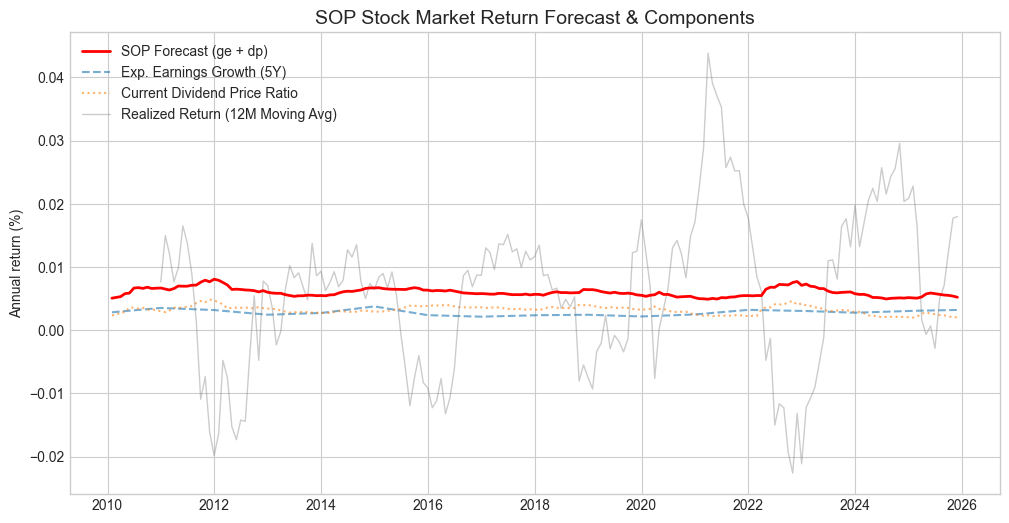

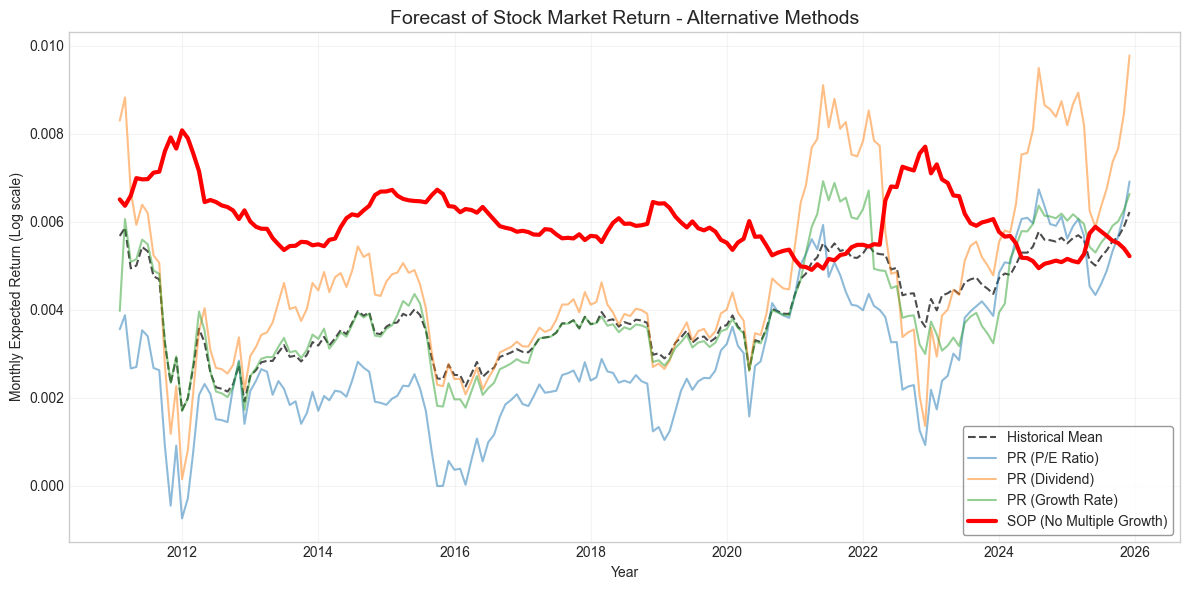

In [9]:
plt.style.use('seaborn-v0_8-whitegrid')

# SOP 預測能力觀察 (成分與趨勢)
fig, ax = plt.subplots(figsize=(12, 6))
# 獲取 5 年移動平均的 ge 與當前 dp 用於繪圖
df['expected_ge_5y'] = df['ge'].rolling(window=60).mean()
sop_comp = df[['expected_ge_5y', 'dp']].loc[start_date:]

# 繪製 SOP 預測路徑
ax.plot(forecast_results['SOP'], label='SOP Forecast (ge + dp)', color='red', linewidth=2, zorder=5)
# 繪製組成成分
ax.plot(sop_comp['expected_ge_5y'], label='Exp. Earnings Growth (5Y)', linestyle='--', alpha=0.6)
ax.plot(sop_comp['dp'], label='Current Dividend Price Ratio', linestyle=':', alpha=0.6)

# 繪製 12 個月平滑後的真實報酬以對比趨勢
realized_smooth = realized.rolling(window=12).mean()
ax.plot(realized_smooth, label='Realized Return (12M Moving Avg)', color='gray', alpha=0.4, linewidth=1)

ax.set_title('SOP Stock Market Return Forecast & Components', fontsize=14)
ax.set_ylabel('Annual return (%)')
ax.legend(loc='upper left')
plt.show()


# 各模型預測結果路徑對比 (選擇從2011開始畫，因為前面 P/E ratio 有出現異常高的現象)
forecast_plot = forecast_results[forecast_results.index >= '2011-01-01'] 
plt.figure(figsize=(12, 6))

# 基準：歷史平均
plt.plot(forecast_plot['HM'], label='Historical Mean', color='black', linestyle='--', alpha=0.7)

# 傳統預測回歸系列 (PR) - 這些模型在 2010 年因 Beta 估計不穩而出現劇烈跳動
plt.plot(forecast_plot['PR_PE'], label='PR (P/E Ratio)', alpha=0.5)
plt.plot(forecast_plot['PR_Dividend'], label='PR (Dividend)', alpha=0.5)
plt.plot(forecast_plot['PR_growth'], label='PR (Growth Rate)', alpha=0.5)

#  SOP 模型 (No Multiple Growth)
plt.plot(forecast_plot['SOP'], label='SOP (No Multiple Growth)', color='red', linewidth=3, zorder=10)

plt.title('Forecast of Stock Market Return - Alternative Methods', fontsize=14)
plt.ylabel('Monthly Expected Return (Log scale)')
plt.xlabel('Year')
plt.legend(loc='lower right', fontsize=10, frameon=True, framealpha=0.8, edgecolor='gray')
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [10]:
from scipy.stats import pearsonr

# 選擇對應預測區間的數據
ge_analysis = df['ge'].rolling(60).mean().loc[forecast_results.index]
dp_analysis = df['dp'].loc[forecast_results.index]

# 計算相關係數與 P-value
corr_val, p_value = pearsonr(ge_analysis, dp_analysis)

print(f"--- ge 與 dp 的相關性分析 ---")
print(f"相關係數 (Correlation): {corr_val:.4f}")
print(f"P-value: {p_value:.4f}")
print("結論: " + ("顯著相關" if p_value < 0.05 else "不顯著相關 (理想狀態，具備互補性)"))

--- ge 與 dp 的相關性分析 ---
相關係數 (Correlation): -0.1933
P-value: 0.0074
結論: 顯著相關


In [11]:
# 取得真實報酬
realized_val = realized.loc[forecast_results.index]
# 基準：歷史平均的 MSE
mse_hm = np.mean((realized_val - forecast_results['HM'])**2)

# 1. 完整 SOP 的 R2
mse_sop = np.mean((realized_val - forecast_results['SOP'])**2)
r2_sop = 1 - (mse_sop / mse_hm)

# 2. 只有 DP 的 R2 (預測值 = 當前 dp)
mse_dp_only = np.mean((realized_val - df['dp'].loc[forecast_results.index])**2)
r2_dp_only = 1 - (mse_dp_only / mse_hm)

# 3. 只有 GE 的 R2 (預測值 = 5年平均 ge)
mse_ge_only = np.mean((realized_val - ge_analysis)**2)
r2_ge_only = 1 - (mse_ge_only / mse_hm)

print(f"\n--- SOP 成分預測力貢獻 (R2_OOS) ---")
print(f"完整 SOP 模型: {r2_sop*100:.2f}%")
print(f"僅靠股息 (DP): {r2_dp_only*100:.2f}%")
print(f"僅靠成長 (GE): {r2_ge_only*100:.2f}%")


--- SOP 成分預測力貢獻 (R2_OOS) ---
完整 SOP 模型: 0.53%
僅靠股息 (DP): -0.49%
僅靠成長 (GE): -0.03%


### 延伸 - 加入本益比元素

In [42]:
forecast_results_v2 = forecast_results.copy()

for current_date in df_test.index:
    train = df[df.index < current_date].copy()

    # SOP components at t-1
    ge_bar = train['ge'].tail(60).mean()
    dp_last = train['dp'].iloc[-1]              # dp_{t-1}
    ge_last = train['ge'].iloc[-1]              # ge_{t-1}
    logPE_last = np.log(train['PE'].iloc[-1])   # logPE_{t-1}

    y = train['gm'].dropna()  # gm_t

    # =========================================================
    # (1) 單變數 OLS：X = logPE_{t-1}
    # gm_t = a + b * logPE_{t-1}
    # =========================================================
    X_pe = sm.add_constant(np.log(train['PE']).shift(1).rename('logPE_lag')).dropna()
    idx = y.index.intersection(X_pe.index)
    model_pe = sm.OLS(y.loc[idx], X_pe.loc[idx]).fit()

    next_X_pe = pd.DataFrame({'const':[1.0], 'logPE_lag':[logPE_last]})
    gm_hat_pe = model_pe.predict(next_X_pe).iloc[0]

    forecast_results_v2.loc[current_date, 'gm_pred_pe'] = gm_hat_pe
    forecast_results_v2.loc[current_date, 'SOP_Multi_Reg_pe'] = ge_bar + dp_last + gm_hat_pe

    # =========================================================
    # (2) 單變數 OLS：X = dp_{t-1}
    # gm_t = a + b * dp_{t-1}
    # =========================================================
    X_dp = sm.add_constant(train['dp'].shift(1).rename('dp_lag')).dropna()
    idx = y.index.intersection(X_dp.index)
    model_dp = sm.OLS(y.loc[idx], X_dp.loc[idx]).fit()

    next_X_dp = pd.DataFrame({'const':[1.0], 'dp_lag':[dp_last]})
    gm_hat_dp = model_dp.predict(next_X_dp).iloc[0]

    forecast_results_v2.loc[current_date, 'gm_pred_dp'] = gm_hat_dp
    forecast_results_v2.loc[current_date, 'SOP_Multi_Reg_dp'] = ge_bar + dp_last + gm_hat_dp

    # =========================================================
    # (3) 單變數 OLS：X = ge_{t-1}
    # gm_t = a + b * ge_{t-1}
    # =========================================================
    X_ge = sm.add_constant(train['ge'].shift(1).rename('ge_lag')).dropna()
    idx = y.index.intersection(X_ge.index)
    model_ge = sm.OLS(y.loc[idx], X_ge.loc[idx]).fit()

    next_X_ge = pd.DataFrame({'const':[1.0], 'ge_lag':[ge_last]})
    gm_hat_ge = model_ge.predict(next_X_ge).iloc[0]

    forecast_results_v2.loc[current_date, 'gm_pred_ge'] = gm_hat_ge
    forecast_results_v2.loc[current_date, 'SOP_Multi_Reg_ge'] = ge_bar + dp_last + gm_hat_ge

    # =========================================================
    # (可選) 你原本的 Mean Reversion 還是可以留著當另一條
    # =========================================================
    H = 60
    logPE_mean = np.log(train['PE']).tail(H).mean()
    gm_pred_rev = (logPE_mean - logPE_last) / H
    forecast_results_v2.loc[current_date, 'gm_pred_rev'] = gm_pred_rev
    forecast_results_v2.loc[current_date, 'SOP_Multi_Rev'] = ge_bar + dp_last + gm_pred_rev


# =========================================================
# 還原「三種」預測 PE_t ：PE_pred_pe / PE_pred_dp / PE_pred_ge
# logPE_hat_t = logPE_{t-1} + gm_hat_t
# =========================================================
logPE_lag_series = np.log(df['PE']).shift(1).reindex(forecast_results_v2.index)

forecast_results_v2['logPE_pred_pe'] = logPE_lag_series + forecast_results_v2['gm_pred_pe']
forecast_results_v2['PE_pred_pe'] = np.exp(forecast_results_v2['logPE_pred_pe'])

forecast_results_v2['logPE_pred_dp'] = logPE_lag_series + forecast_results_v2['gm_pred_dp']
forecast_results_v2['PE_pred_dp'] = np.exp(forecast_results_v2['logPE_pred_dp'])

forecast_results_v2['logPE_pred_ge'] = logPE_lag_series + forecast_results_v2['gm_pred_ge']
forecast_results_v2['PE_pred_ge'] = np.exp(forecast_results_v2['logPE_pred_ge'])

# (可選) Mean reversion 也能還原一條 PE
forecast_results_v2['logPE_pred_rev'] = logPE_lag_series + forecast_results_v2['gm_pred_rev']
forecast_results_v2['PE_pred_rev'] = np.exp(forecast_results_v2['logPE_pred_rev'])


In [12]:
df = df.copy()
df['logPE'] = np.log(df['PE'])
df['gm'] = df['logPE'] - df['logPE'].shift(1)  # monthly multiple growth

x_list = {
    'PE': 'logPE', 
    'DP': 'dp',
    'GE': 'ge',
}

H_ge = 60  

for i in range(len(df_test)):
    current_date = df_test.index[i]
    train_data = df[df.index < current_date].copy()

    # SOP components at t-1
    ge_bar = train_data['ge'].tail(H_ge).mean()
    dp_last = train_data['dp'].iloc[-1]        # dp_{t-1}
    logPE_last = train_data['logPE'].iloc[-1]  # logPE_{t-1}

    # 針對每個 x 各自估 gm_pred_reg_x 與 gm_pred_rev_x
    for x_name, x_col in x_list.items():
        x_series = train_data[x_col].copy()
        x_last = x_series.iloc[-1]


        # (A) Multiple Growth Regression
        # gm_t = a + b * x_{t-1}
        y = train_data['gm'].dropna()
        X = sm.add_constant(x_series.shift(1).rename('x_lag'), has_constant='add').dropna()
        idx = y.index.intersection(X.index)

        if len(idx) >= 36: # 避免太短樣本不穩
            model_reg = sm.OLS(y.loc[idx], X.loc[idx]).fit()

            next_X = pd.DataFrame({'x_lag': [x_last]})
            next_X = sm.add_constant(next_X, has_constant='add')
            gm_pred_reg = model_reg.predict(next_X).iloc[0]
        else:
            gm_pred_reg = np.nan

        forecast_results.loc[current_date, f'gm_reg_{x_name}'] = gm_pred_reg
        forecast_results.loc[current_date, f'SOP_reg_{x_name}'] = ge_bar + dp_last + gm_pred_reg


        # (B) Multiple Reversion
        # Step1: m_t = a + b x_t + u_t,  m_t = logPE_t
        # Step2: gm_{t+1} = c + d(-u_t) + v_{t+1}
        # Forecast: gm_t = c_hat + d_hat * (-(u_{t-1}))
        m = train_data['logPE'].dropna()
        X1 = sm.add_constant(x_series, has_constant='add').dropna()
        idx1 = m.index.intersection(X1.index)

        gm_pred_rev = np.nan
        if len(idx1) >= 60:
            model_m = sm.OLS(m.loc[idx1], X1.loc[idx1]).fit()
            mhat = model_m.predict(X1.loc[idx1])
            # u_t 為當期估值偏離
            u = (m.loc[idx1] - mhat)  
            neg_u = (-u).rename('neg_u') 

            gm_lead = train_data['gm'].shift(-1)  # gm_{t+1}
            step2 = pd.concat([gm_lead, neg_u], axis=1).dropna()
            step2.columns = ['gm_lead', 'neg_u']

            if len(step2) >= 60:
                X2 = sm.add_constant(step2[['neg_u']], has_constant='add')
                model2 = sm.OLS(step2['gm_lead'], X2).fit()

                # u_{t-1}：train 最後一期是 t-1
                m_last = logPE_last

                last_X1 = pd.DataFrame({x_col: [x_last]})
                last_X1 = sm.add_constant(last_X1, has_constant='add')
                mhat_last = model_m.predict(last_X1).iloc[0]

                u_last = m_last - mhat_last
                neg_u_last = -u_last

                next_X2 = pd.DataFrame({'neg_u': [neg_u_last]})
                next_X2 = sm.add_constant(next_X2, has_constant='add')
                gm_pred_rev = model2.predict(next_X2).iloc[0]

        forecast_results.loc[current_date, f'gm_rev_{x_name}'] = gm_pred_rev
        forecast_results.loc[current_date, f'SOP_rev_{x_name}'] = ge_bar + dp_last + gm_pred_rev

In [ ]:
gm_oos_table = []

# 基準：gm_hat = 0
gm_real2 = df['gm'].reindex(forecast_results.index)

for x_name in x_list.keys():
    for typ in ['reg', 'rev']:
        pred = forecast_results[f'gm_{typ}_{x_name}']
        tmp = pd.concat([gm_real2, pred], axis=1).dropna()
        tmp.columns = ['gm', 'pred']

        mse_model = np.mean((tmp['gm'] - tmp['pred'])**2)
        mse_rw = np.mean((tmp['gm'] - 0.0)**2)  # baseline gm=0

        r2_oos = 1 - mse_model / mse_rw

        gm_oos_table.append({
            'Variable': x_name,
            'Method': 'GM regression' if typ=='reg' else 'GM reversion',
            'OOS_R2(%)': r2_oos * 100
        })

gm_oos_df = pd.DataFrame(gm_oos_table).pivot(index='Variable', columns='Method', values='OOS_R2(%)')
display(gm_oos_df)


Method,GM regression,GM reversion
Variable,,
DP,-0.114948,-12.011821
GE,6.024199,1.583797
PE,-3.894281,-5.062840


In [ ]:
# realized return aligned to forecast index
realized = df_test['r'].reindex(forecast_results.index)

oos_table = []

# HM 數據對齊
hm = forecast_results['HM'].reindex(realized.index)

for x_name in x_list.keys():
    for typ in ['reg', 'rev']:
        col = f'SOP_{typ}_{x_name}' 

        # 三者共同樣本：y, hm, model forecast
        tmp = pd.concat([realized, hm, forecast_results[col]], axis=1).dropna()
        tmp.columns = ['y', 'hm', 'm']

        # OOS R^2 vs HM
        mse_m  = np.mean((tmp['y'] - tmp['m'])**2)
        mse_hm = np.mean((tmp['y'] - tmp['hm'])**2)
        r2_oos = 1 - mse_m / mse_hm

        oos_table.append({
            'Variable': x_name,
            'Method': 'SOP with multiple growth regression' if typ=='reg' else 'SOP with multiple reversion',
            'OOS_R2(%)': r2_oos * 100,
            'N': len(tmp)   
        })

oos_df = (
    pd.DataFrame(oos_table)
      .pivot(index='Variable', columns='Method', values='OOS_R2(%)')
)

display(oos_df)

n_df = (
    pd.DataFrame(oos_table)
      .pivot(index='Variable', columns='Method', values='N')
)
display(n_df)


Method,SOP with multiple growth regression,SOP with multiple reversion
Variable,,
DP,-23.776944,-16.588090
GE,-171.270000,-28.372050
PE,-21.799026,-0.470761


Method,SOP with multiple growth regression,SOP with multiple reversion
Variable,,
DP,191,190
GE,191,190
PE,191,190


#### 月頻

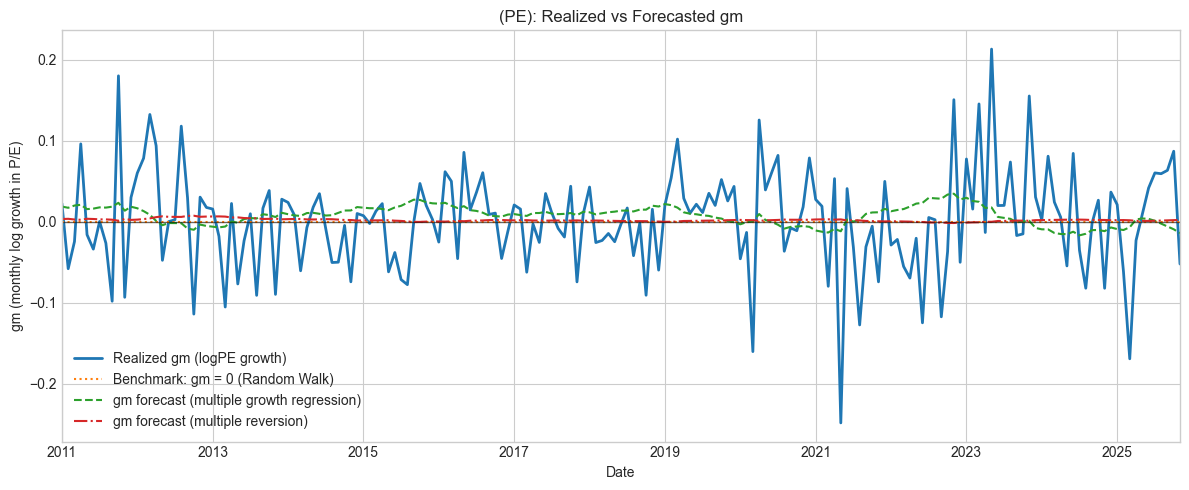

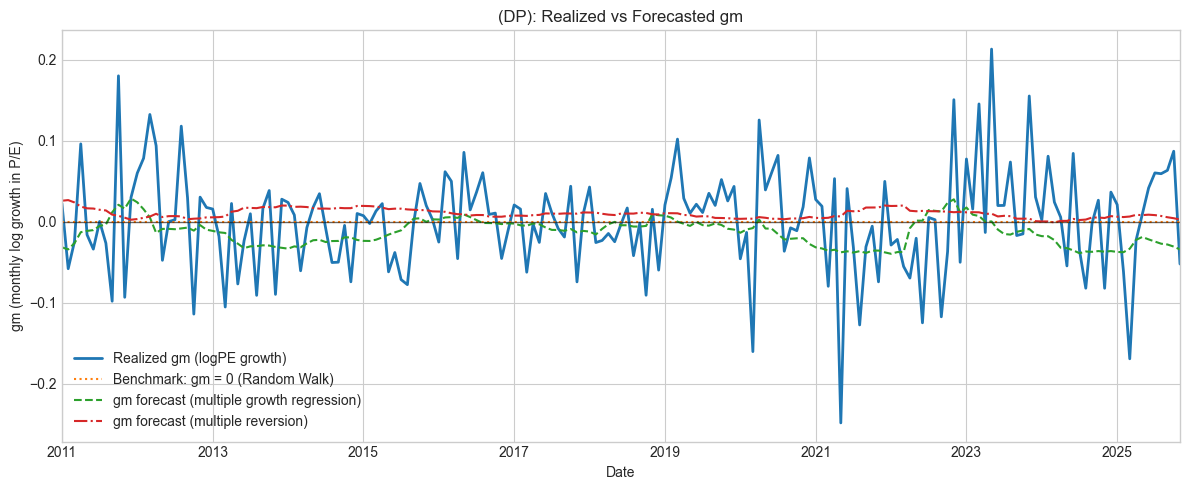

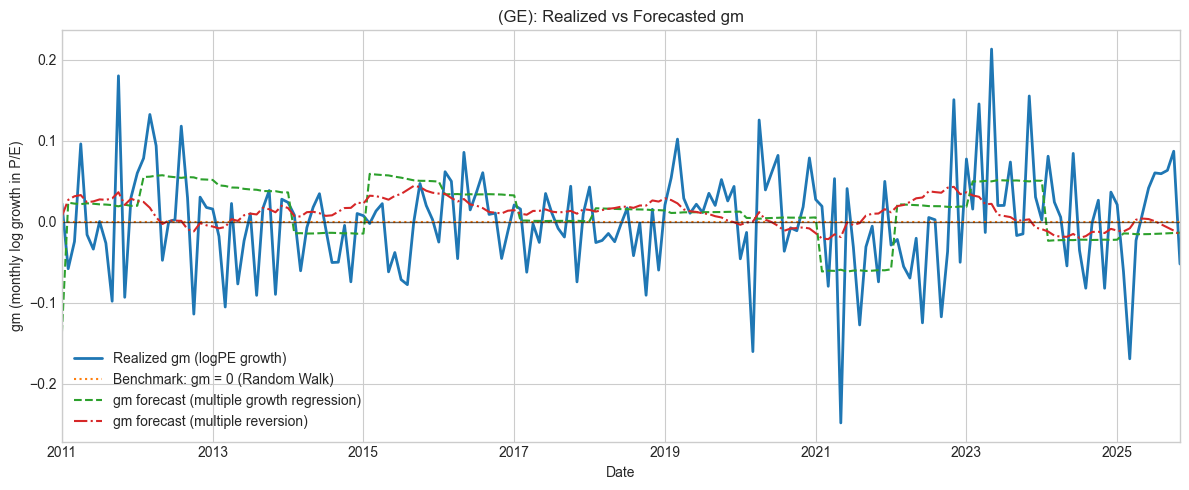

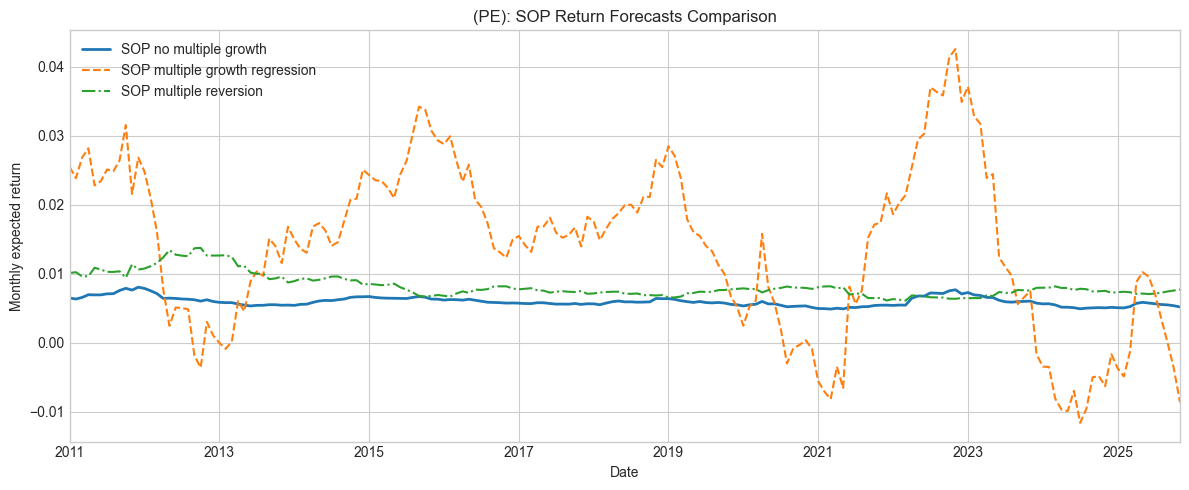

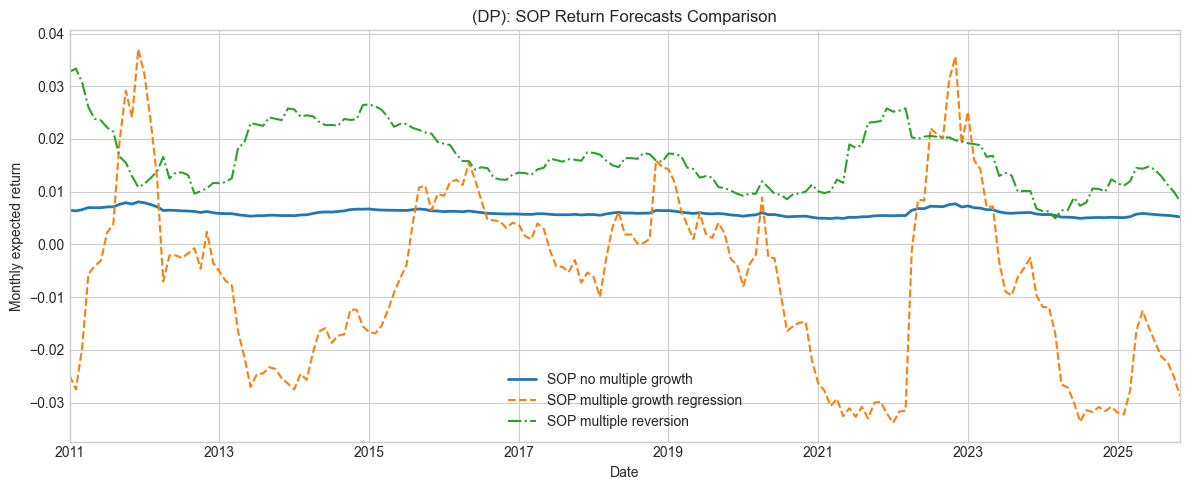

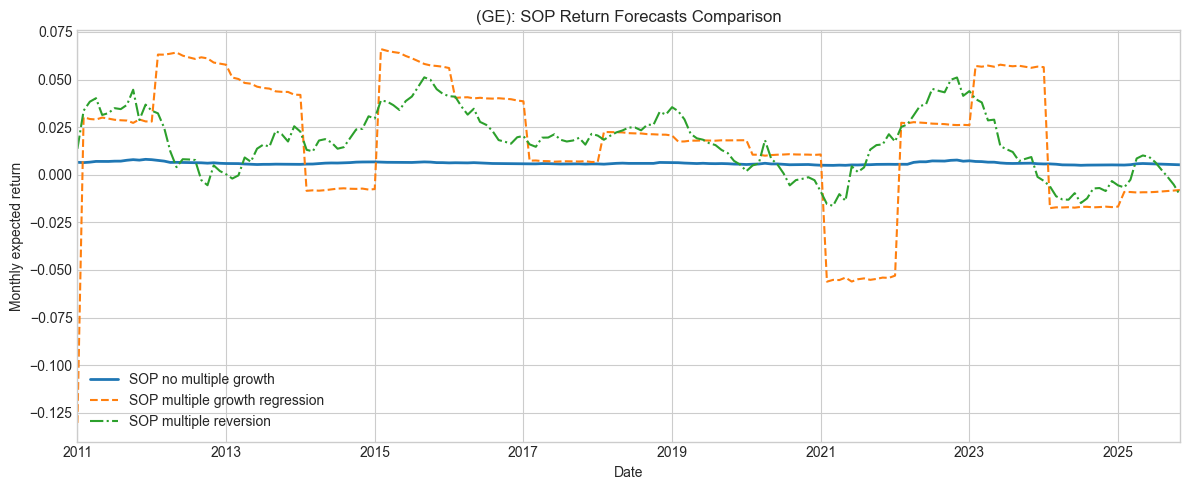

In [ ]:
plot_start = '2011-01-01'

# realized gm 對齊 forecast_results 的 index
gm_real = df['gm'].reindex(forecast_results.index)

for x_name in x_list.keys():
    plt.figure(figsize=(12,5))

    # 1. Realized gm
    gm_real.loc[plot_start:].plot(label='Realized gm (logPE growth)', linewidth=2)

    # 2. Baseline: Random Walk implies gm_hat = 0
    gm_zero = pd.Series(0.0, index=forecast_results.index)
    gm_zero.loc[plot_start:].plot(label='Benchmark: gm = 0 (Random Walk)', linestyle=':')

    # 3. Model forecasts
    forecast_results.loc[plot_start:, f'gm_reg_{x_name}'] \
        .plot(label='gm forecast (multiple growth regression)', linestyle='--')

    forecast_results.loc[plot_start:, f'gm_rev_{x_name}'] \
        .plot(label='gm forecast (multiple reversion)', linestyle='-.')

    plt.title(f'({x_name}): Realized vs Forecasted gm')
    plt.ylabel('gm (monthly log growth in P/E)')
    plt.axhline(0, color='black', linewidth=1, alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()


for x_name in x_list.keys():
    plt.figure(figsize=(12,5))

    forecast_results.loc[plot_start:, 'SOP'] \
        .plot(label='SOP no multiple growth', linewidth=2)

    forecast_results.loc[plot_start:, f'SOP_reg_{x_name}'] \
        .plot(label='SOP multiple growth regression', linestyle='--')

    forecast_results.loc[plot_start:, f'SOP_rev_{x_name}'] \
        .plot(label='SOP multiple reversion', linestyle='-.')

    plt.title(f'({x_name}): SOP Return Forecasts Comparison')
    plt.ylabel('Monthly expected return')
    plt.legend()
    plt.tight_layout()
    plt.show()

#### 年頻

In [ ]:
plot_start = '2011-01-01'

# Monthly series
gm_real_m = df['gm'].reindex(forecast_results.index)
gm_zero_m = pd.Series(0.0, index=forecast_results.index)

# 年頻：用 calendar year 平均
gm_real_y = gm_real_m.loc[plot_start:].resample('Y').mean()
gm_zero_y = gm_zero_m.loc[plot_start:].resample('Y').mean()


C:\Users\Joker Jeff\AppData\Local\Temp\ipykernel_20116\1406668967.py:8: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  gm_real_y = gm_real_m.loc[plot_start:].resample('Y').mean()
C:\Users\Joker Jeff\AppData\Local\Temp\ipykernel_20116\1406668967.py:9: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  gm_zero_y = gm_zero_m.loc[plot_start:].resample('Y').mean()


C:\Users\Joker Jeff\AppData\Local\Temp\ipykernel_20116\1168435669.py:12: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  .loc[plot_start:].resample('Y').mean() \
C:\Users\Joker Jeff\AppData\Local\Temp\ipykernel_20116\1168435669.py:16: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  .loc[plot_start:].resample('Y').mean() \


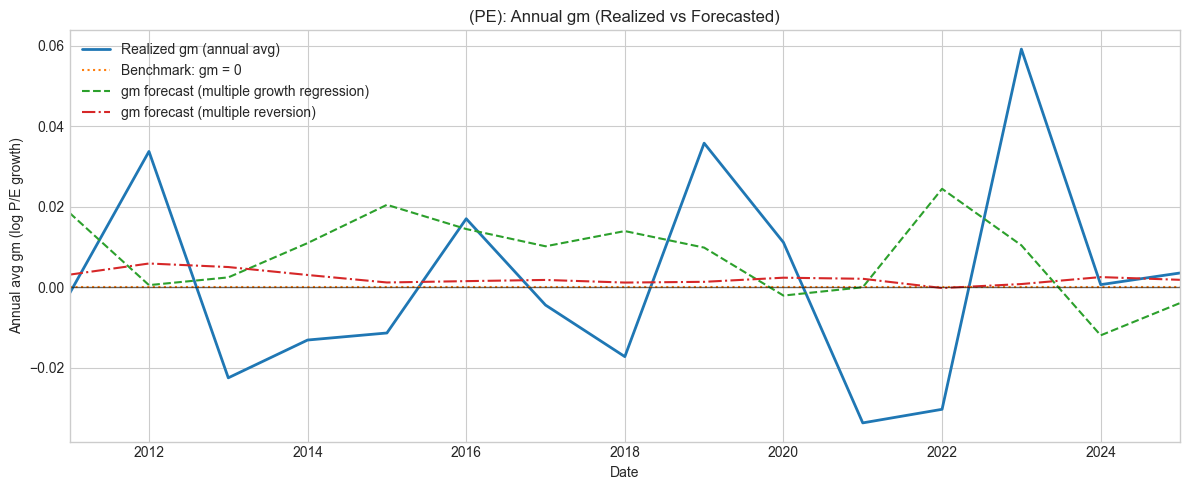

C:\Users\Joker Jeff\AppData\Local\Temp\ipykernel_20116\1168435669.py:12: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  .loc[plot_start:].resample('Y').mean() \
C:\Users\Joker Jeff\AppData\Local\Temp\ipykernel_20116\1168435669.py:16: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  .loc[plot_start:].resample('Y').mean() \


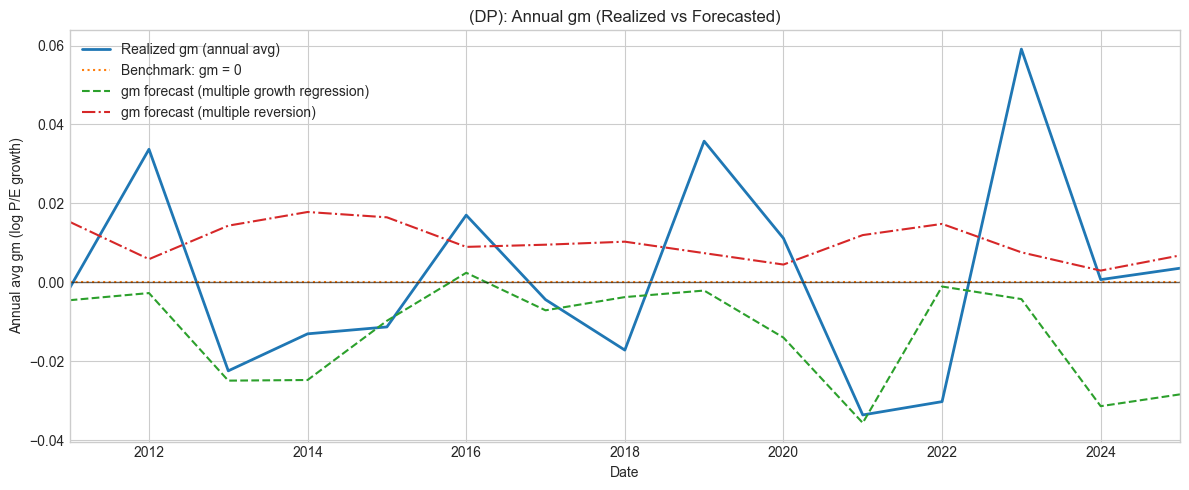

C:\Users\Joker Jeff\AppData\Local\Temp\ipykernel_20116\1168435669.py:12: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  .loc[plot_start:].resample('Y').mean() \
C:\Users\Joker Jeff\AppData\Local\Temp\ipykernel_20116\1168435669.py:16: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  .loc[plot_start:].resample('Y').mean() \


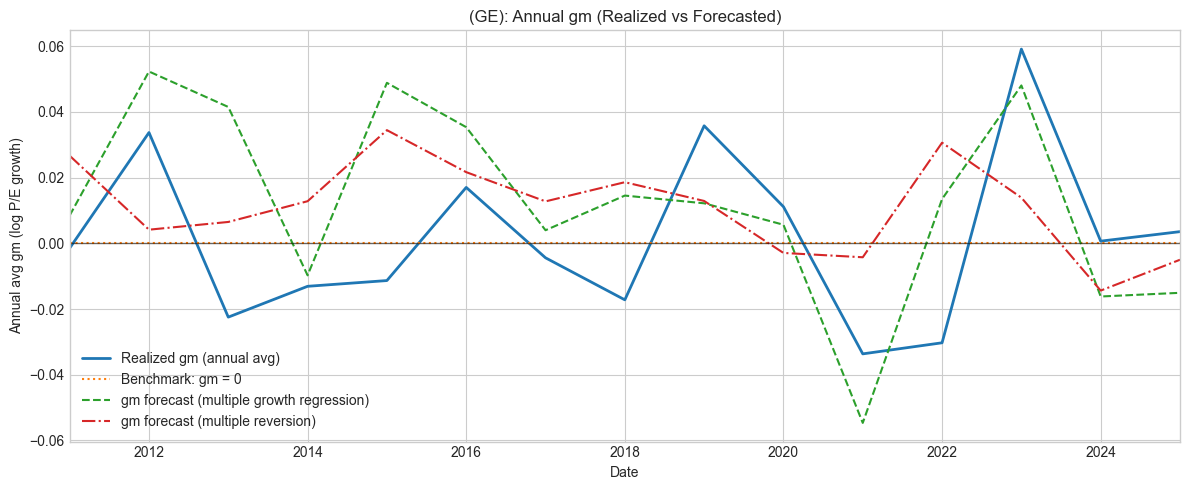

In [19]:
for x_name in x_list.keys():
    plt.figure(figsize=(12,5))

    # 年頻 realized gm
    gm_real_y.plot(label='Realized gm (annual avg)', linewidth=2)

    # Benchmark
    gm_zero_y.plot(label='Benchmark: gm = 0', linestyle=':')

    # 年頻 forecast
    forecast_results[f'gm_reg_{x_name}'] \
        .loc[plot_start:].resample('Y').mean() \
        .plot(label='gm forecast (multiple growth regression)', linestyle='--')

    forecast_results[f'gm_rev_{x_name}'] \
        .loc[plot_start:].resample('Y').mean() \
        .plot(label='gm forecast (multiple reversion)', linestyle='-.')

    plt.axhline(0, color='black', linewidth=1, alpha=0.5)
    plt.title(f'({x_name}): Annual gm (Realized vs Forecasted)')
    plt.ylabel('Annual avg gm (log P/E growth)')
    plt.legend()
    plt.tight_layout()
    plt.show()


In [20]:
# Monthly realized return
r_m = df['r'].reindex(forecast_results.index)

# 年頻（平均 × 12 → 年化）
r_y = r_m.loc[plot_start:].resample('Y').mean() * 12

C:\Users\Joker Jeff\AppData\Local\Temp\ipykernel_20116\703336728.py:5: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  r_y = r_m.loc[plot_start:].resample('Y').mean() * 12


C:\Users\Joker Jeff\AppData\Local\Temp\ipykernel_20116\2660851976.py:7: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  .resample('Y').mean() * 12
C:\Users\Joker Jeff\AppData\Local\Temp\ipykernel_20116\2660851976.py:13: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  .resample('Y').mean() * 12
C:\Users\Joker Jeff\AppData\Local\Temp\ipykernel_20116\2660851976.py:19: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  .resample('Y').mean() * 12


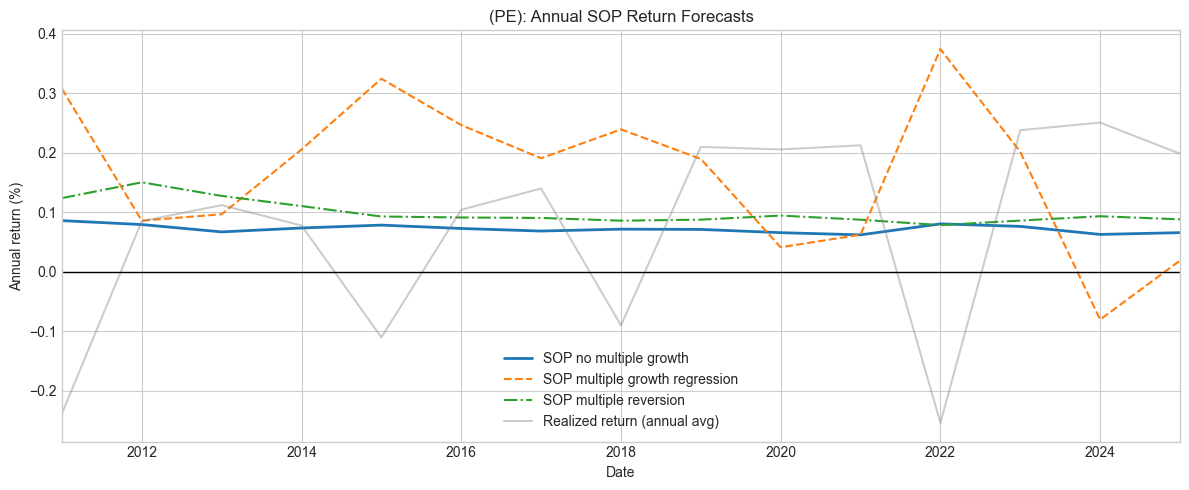

C:\Users\Joker Jeff\AppData\Local\Temp\ipykernel_20116\2660851976.py:7: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  .resample('Y').mean() * 12
C:\Users\Joker Jeff\AppData\Local\Temp\ipykernel_20116\2660851976.py:13: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  .resample('Y').mean() * 12
C:\Users\Joker Jeff\AppData\Local\Temp\ipykernel_20116\2660851976.py:19: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  .resample('Y').mean() * 12


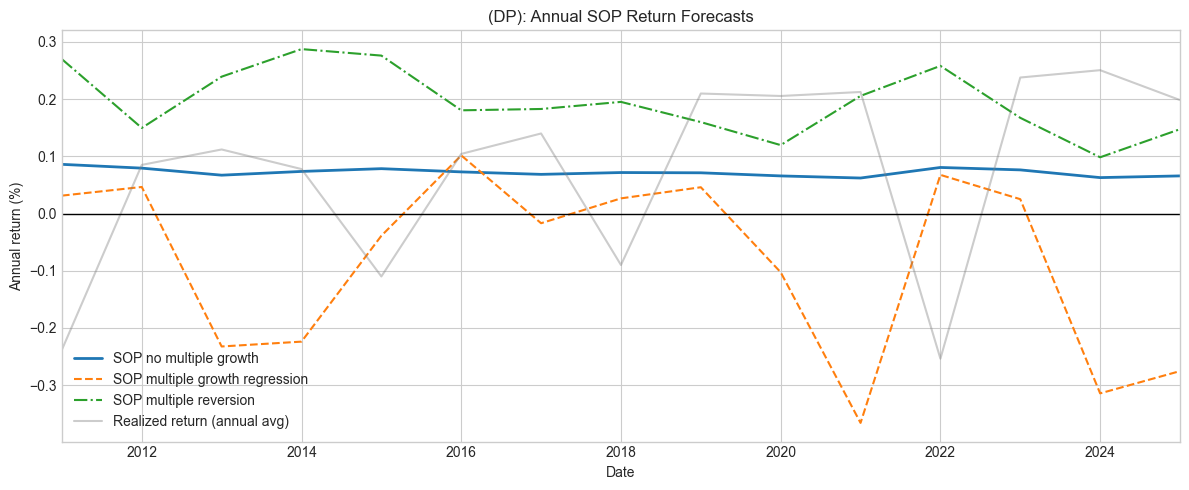

C:\Users\Joker Jeff\AppData\Local\Temp\ipykernel_20116\2660851976.py:7: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  .resample('Y').mean() * 12
C:\Users\Joker Jeff\AppData\Local\Temp\ipykernel_20116\2660851976.py:13: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  .resample('Y').mean() * 12
C:\Users\Joker Jeff\AppData\Local\Temp\ipykernel_20116\2660851976.py:19: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  .resample('Y').mean() * 12


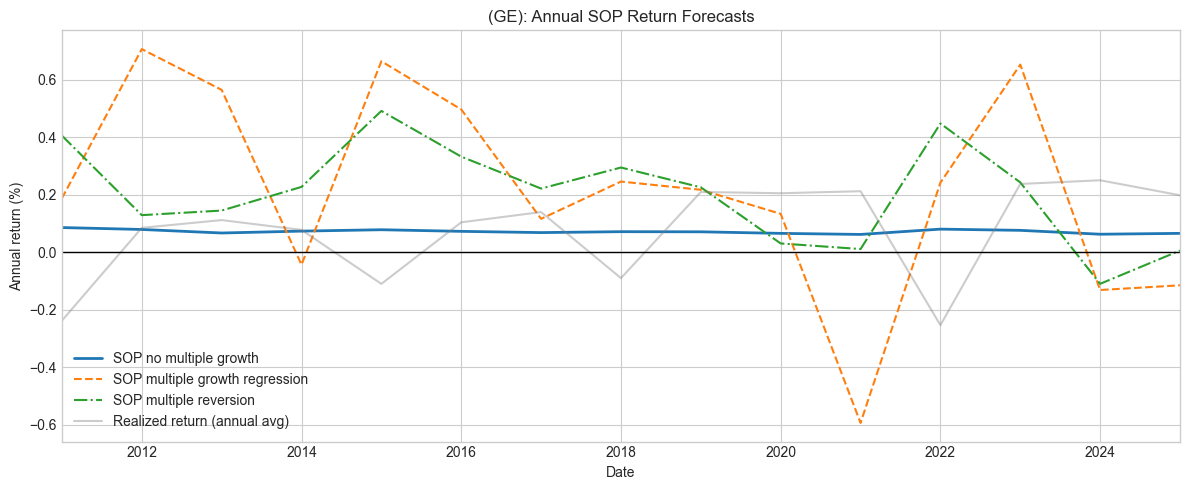

In [21]:
for x_name in x_list.keys():
    plt.figure(figsize=(12,5))

    # SOP no multiple growth
    (forecast_results['SOP']
        .loc[plot_start:]
        .resample('Y').mean() * 12
    ).plot(label='SOP no multiple growth', linewidth=2)

    # SOP with multiple growth regression
    (forecast_results[f'SOP_reg_{x_name}']
        .loc[plot_start:]
        .resample('Y').mean() * 12
    ).plot(label='SOP multiple growth regression', linestyle='--')

    # SOP with multiple reversion
    (forecast_results[f'SOP_rev_{x_name}']
        .loc[plot_start:]
        .resample('Y').mean() * 12
    ).plot(label='SOP multiple reversion', linestyle='-.')

    # Realized annual return (optional, paper-like)
    r_y.plot(label='Realized return (annual avg)', color='gray', alpha=0.4)

    plt.axhline(0, color='black', linewidth=1)
    plt.title(f'({x_name}): Annual SOP Return Forecasts')
    plt.ylabel('Annual return (%)')
    plt.legend()
    plt.tight_layout()
    plt.show()


### 其他 - 蒙地卡羅

SOP 類模型高度依賴「估值–報酬的長期 equilibrium 校準」
一旦市場結構不同（如台灣），SOP 會產生巨大的系統性偏誤


=== Panel A: RMSE (×100) ===
                Mean        10%        25%     Median         75%         90%
HM         16.340543   9.303362  11.600303  15.238432   19.816424   25.045660
PR         17.079022  10.504236  12.924050  16.220113   20.297128   24.728397
SOP_fixed  79.163809  38.455389  50.511755  70.495506  100.110462  132.338596
SOP_adj    43.625544  25.241084  31.649723  40.696827   52.865379   65.551543
SOP_est    64.231942  29.175024  39.485553  55.946258   82.283697  111.116605

=== Panel B: MSE decomposition (×1000) ===
                       HM         PR   SOP_fixed       SOP_adj     SOP_est
Square bias     16.182878  11.840421  555.481281  7.421783e-30  288.063878
Var(estimator)   2.821861  16.414699  161.683977  1.616840e+02  200.424171
Var(true mu)     6.989082   6.989082    6.989082  6.989082e+00    6.989082
-2Cov(est,mu)    4.746473  -2.745994   48.700372  4.870037e+01   30.077688
MSE             30.740294  32.498208  772.854713  2.173734e+02  525.554819

=== SOP

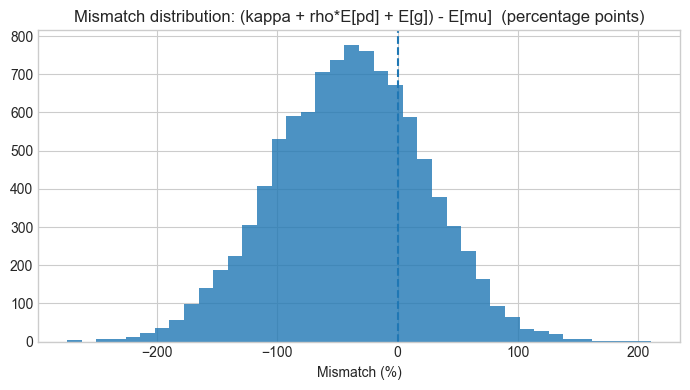

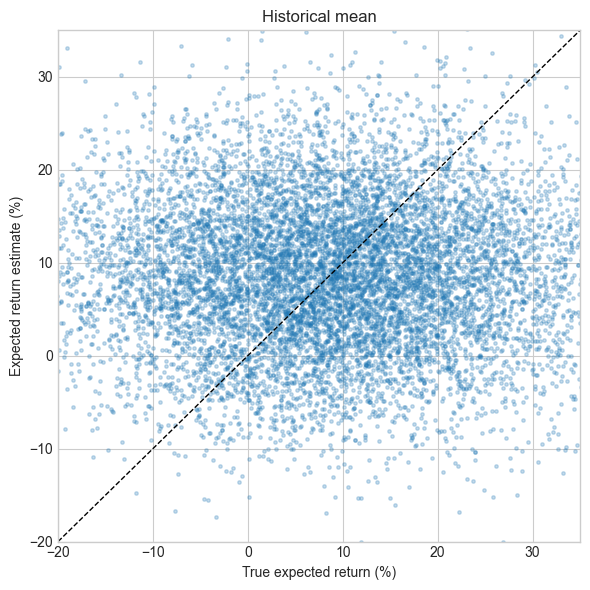

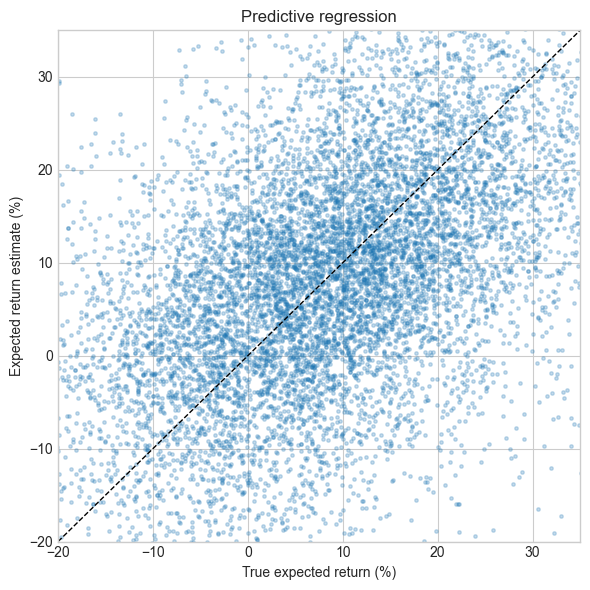

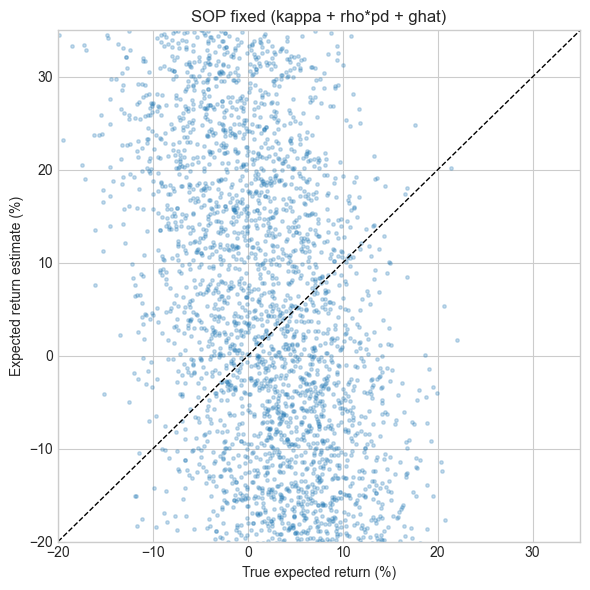

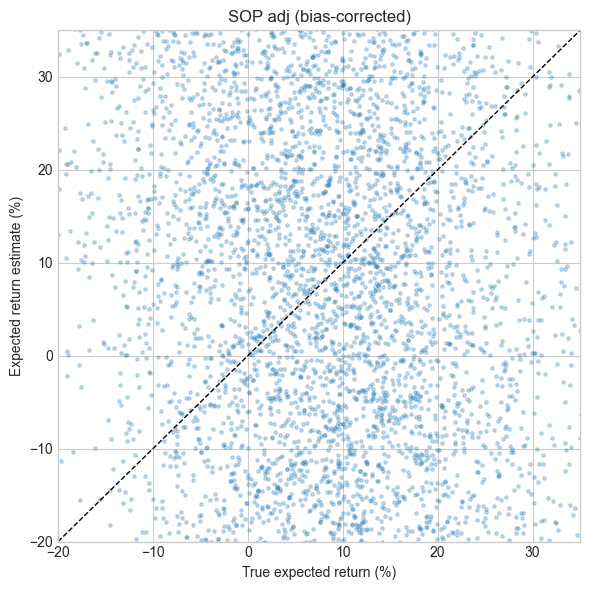

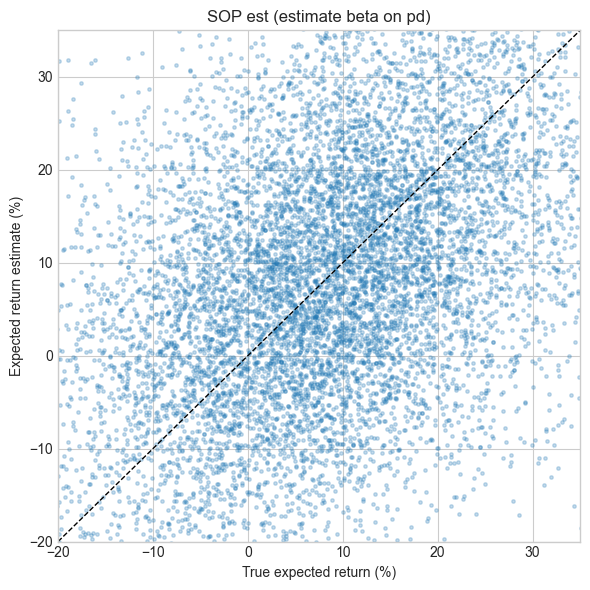

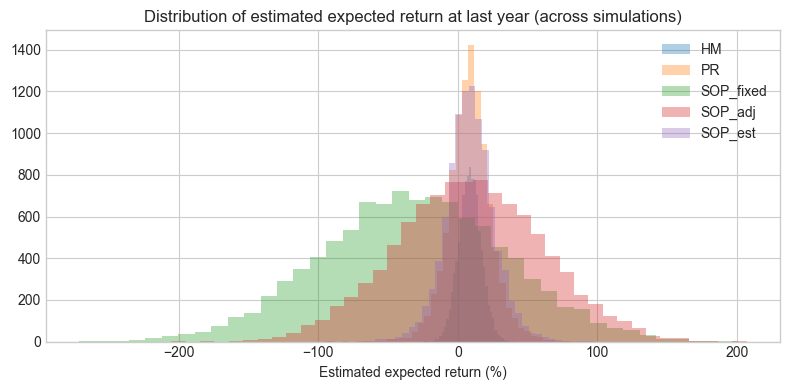

In [28]:
# 參數區（請用你台灣市場校準值替換）
params = {
    # μ_{t+1} = δ0 + δ1(μ_t-δ0) + ε^μ
    "delta0": 0.085,   # E[μ] 年化
    "delta1": 0.90,
    "sigma_mu": 0.06,

    # g_{t+1} = γ0 + γ1(g_t-γ0) + ε^g
    "gamma0": 0.045,   # E[g] 年化
    "gamma1": 0.50,
    "sigma_g": 0.025,

    # Δd_{t+1} = g_t + ε^d
    "sigma_d": 0.15,

    # CS log-linear constants
    "rho": 0.90,
    "kappa": 0.00,
}


# 1.Monte Carlo 設定
N_SIM    = 10000      # 先用 2000~5000 測，確定 OK 再開 10000
T_REAL   = 20        # 要保留的樣本長度（年）
BURN_IN  = 200       # burn-in 建議 >= 200
T_TOTAL  = BURN_IN + T_REAL

S0       = 5        # OOS 起點（前 S0 年當 in-sample）
SOP_SMOOTH = 5      # ĝ 用過去幾年平滑
PD_CLIP  = (-3.0, 6.0)  # log(P/D) 的合理範圍（你可依台灣估值調整，例如 (-2, 5)）

SEED = 42
rng = np.random.default_rng(SEED)

# =========================================================
# 2) 核心：模擬一條經濟路徑（年頻）
# =========================================================
def simulate_one_path(params, T_total, burn_in, T_real, rng, pd_clip=(-3.0, 6.0)):
    delta0, delta1, sigma_mu = params["delta0"], params["delta1"], params["sigma_mu"]
    gamma0, gamma1, sigma_g  = params["gamma0"], params["gamma1"], params["sigma_g"]
    sigma_d = params["sigma_d"]
    rho, kappa = params["rho"], params["kappa"]

    # Eq(30) constants (Campbell-Shiller implied)
    B1 = 1.0 / (1.0 - rho * delta1)
    B2 = 1.0 / (1.0 - rho * gamma1)
    A  = (kappa + (gamma0 - delta0)) / (1.0 - rho)

    # simulate latent states
    mu = np.zeros(T_total + 1)
    g  = np.zeros(T_total + 1)
    mu[0] = delta0
    g[0]  = gamma0

    eps_mu = rng.normal(0, sigma_mu, size=T_total)
    eps_g  = rng.normal(0, sigma_g,  size=T_total)
    eps_d  = rng.normal(0, sigma_d,  size=T_total)

    for t in range(T_total):
        mu[t+1] = delta0 + delta1*(mu[t] - delta0) + eps_mu[t]
        g[t+1]  = gamma0 + gamma1*(g[t]  - gamma0) + eps_g[t]

    # build pd, dp (pd = p-d = log(P/D), dp = d-p = log(D/P))
    pd = np.zeros(T_total + 1)
    dp = np.zeros(T_total + 1)
    for t in range(T_total + 1):
        pd_t = A - B1*(mu[t] - delta0) + B2*(g[t] - gamma0)
        pd[t] = np.clip(pd_t, pd_clip[0], pd_clip[1])
        dp[t] = -pd[t]

    # realized dividend growth: Δd_{t+1} = g_t + ε^d_{t+1}
    dd = g[:-1] + eps_d  # length T_total

    # realized returns via Eq(29): r_{t+1} = κ + ρ*pd_{t+1} + Δd_{t+1} - pd_t
    r = np.zeros(T_total)
    for t in range(T_total):
        r[t] = kappa + rho*pd[t+1] + dd[t] - pd[t]

    # drop burn-in, align to length T_real
    mu_real = mu[burn_in:burn_in + T_real]
    g_real  = g[burn_in:burn_in + T_real]
    pd_real = pd[burn_in:burn_in + T_real]
    dp_real = dp[burn_in:burn_in + T_real]
    dd_real = dd[burn_in:burn_in + T_real]
    r_real  = r[burn_in:burn_in + T_real]

    return {"mu": mu_real, "g": g_real, "pd": pd_real, "dp": dp_real, "dd": dd_real, "r": r_real}

# =========================================================
# 3) OOS forecasting：HM / PR / SOP_fixed / SOP_adj / SOP_est
# =========================================================
def oos_forecast_one_path(path, S0=20, sop_smooth=10, rho=0.96, kappa=0.0):
    mu = path["mu"]   # true expected return (annual)
    r  = path["r"]    # realized return
    dp = path["dp"]   # log(D/P)
    pd = path["pd"]   # log(P/D)
    dd = path["dd"]   # realized dividend growth

    T = len(mu)

    hm  = np.full(T, np.nan)
    pr  = np.full(T, np.nan)
    sop_fixed = np.full(T, np.nan)
    sop_est   = np.full(T, np.nan)

    # --- helper: rolling g-hat ---
    def ghat_from_past(dd_train, w):
        w = min(w, len(dd_train))
        return np.mean(dd_train[-w:]) if w > 0 else np.nan

    for t in range(S0, T):
        # train uses 0..t-1
        r_train  = r[:t]
        dp_train = dp[:t]
        pd_train = pd[:t]
        dd_train = dd[:t]

        # (1) HM
        hm[t] = np.mean(r_train)

        # (2) PR: r_{s+1} = a + b * dp_s
        X = dp_train[:-1]  # dp_0..dp_{t-2}
        Y = r_train[1:]    # r_1..r_{t-1}
        if len(X) >= 10 and np.var(X) > 1e-12:
            b = np.cov(X, Y, bias=True)[0, 1] / np.var(X)
            a = np.mean(Y) - b*np.mean(X)
            pr[t] = a + b*dp[t-1]
        else:
            pr[t] = np.mean(r_train)

        # (3) SOP_fixed: κ + ρ*pd_{t-1} + ghat_t
        ghat = ghat_from_past(dd_train, sop_smooth)
        sop_fixed[t] = kappa + rho*pd[t-1] + ghat

        # (4) SOP_est: κ + β*pd_{t-1} + ghat_t  (β 用資料估)
        # 用訓練樣本回歸 r_{s+1} - ghat_s  on  pd_s
        # ghat_s 也用 rolling 的方式算（避免未來資訊）
        if len(r_train) >= 15:
            ghat_series = np.array([ghat_from_past(dd[:s], sop_smooth) for s in range(1, t)])  # s=1..t-1
            y = r_train[1:] - ghat_series  # align with pd_0..pd_{t-2}
            x = pd_train[:-1]
            if np.all(np.isfinite(y)) and np.var(x) > 1e-12:
                beta = np.cov(x, y, bias=True)[0, 1] / np.var(x)
                alpha = np.mean(y) - beta*np.mean(x)
                sop_est[t] = kappa + (alpha + beta*pd[t-1]) + ghat
            else:
                sop_est[t] = sop_fixed[t]
        else:
            sop_est[t] = sop_fixed[t]

    # (5) SOP_adj: 把 SOP_fixed 的「OOS 均值偏差」扣掉，做公平比較
    # 只用 OOS 區間的均值進行 re-centering（每條 path 自己校正）
    sop_adj = sop_fixed.copy()
    oos_idx = np.arange(S0, T)
    if np.any(np.isfinite(sop_fixed[oos_idx])):
        bias = np.nanmean(sop_fixed[oos_idx]) - np.nanmean(mu[oos_idx])
        sop_adj[oos_idx] = sop_fixed[oos_idx] - bias

    return mu, hm, pr, sop_fixed, sop_adj, sop_est

# =========================================================
# 4) MSE decomposition (Eq.31 sample analog)
# =========================================================
def mse_decomposition(mu_true, mu_hat, S0):
    idx = np.arange(S0, len(mu_true))
    x = mu_hat[idx]
    y = mu_true[idx]
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]; y = y[mask]
    if len(x) < 5:
        return (np.nan, np.nan, np.nan, np.nan, np.nan)

    e = x - y
    bias2 = (np.mean(x) - np.mean(y))**2
    var_hat = np.var(x, ddof=0)
    var_true = np.var(y, ddof=0)
    cov_term = -2.0 * np.cov(x, y, ddof=0)[0, 1]
    mse = np.mean(e**2)
    return bias2, var_hat, var_true, cov_term, mse

def summarize_rmse(rmse_arr):
    rmse_arr = np.array(rmse_arr)
    return {
        "Mean":   np.mean(rmse_arr)*100,
        "10%":    np.percentile(rmse_arr, 10)*100,
        "25%":    np.percentile(rmse_arr, 25)*100,
        "Median": np.percentile(rmse_arr, 50)*100,
        "75%":    np.percentile(rmse_arr, 75)*100,
        "90%":    np.percentile(rmse_arr, 90)*100,
    }

def summarize_decomp(decomp_list):
    arr = np.array([d for d in decomp_list if np.all(np.isfinite(d))])
    if len(arr) == 0:
        return pd.Series({"Square bias": np.nan, "Var(estimator)": np.nan, "Var(true mu)": np.nan, "-2Cov(est,mu)": np.nan, "MSE": np.nan})
    m = arr.mean(axis=0)
    return pd.Series({
        "Square bias":     m[0]*1000,
        "Var(estimator)":  m[1]*1000,
        "Var(true mu)":    m[2]*1000,
        "-2Cov(est,mu)":   m[3]*1000,
        "MSE":             m[4]*1000,
    })

# =========================================================
# 5) 跑 Monte Carlo + 收集 Fig8 散點 + mismatch 診斷
# =========================================================
methods = ["HM", "PR", "SOP_fixed", "SOP_adj", "SOP_est"]

rmse_list = {m: [] for m in methods}
decomp_list = {m: [] for m in methods}

scatter_true = {m: [] for m in methods}
scatter_hat  = {m: [] for m in methods}

# mismatch diagnostic
mismatch_records = []

rho = params["rho"]; kappa = params["kappa"]

for s in range(N_SIM):
    path = simulate_one_path(params, T_TOTAL, BURN_IN, T_REAL, rng, pd_clip=PD_CLIP)
    mu, hm, pr, sop_fixed, sop_adj, sop_est = oos_forecast_one_path(
        path, S0=S0, sop_smooth=SOP_SMOOTH, rho=rho, kappa=kappa
    )

    # --- mismatch diagnostic for this path (OOS region) ---
    oos = np.arange(S0, T_REAL)
    mu_bar = np.mean(mu[oos])
    g_bar  = np.mean(path["g"][oos])
    pd_bar = np.mean(path["pd"][oos])
    sop_level_bar = kappa + rho*pd_bar + g_bar
    mismatch_records.append([mu_bar, sop_level_bar, (sop_level_bar - mu_bar), pd_bar, g_bar])

    # --- evaluate methods ---
    series_map = {
        "HM": hm,
        "PR": pr,
        "SOP_fixed": sop_fixed,
        "SOP_adj": sop_adj,
        "SOP_est": sop_est,
    }

    # RMSE on OOS
    idx = np.arange(S0, T_REAL)
    for name, muhat in series_map.items():
        x = muhat[idx]
        y = mu[idx]
        mask = np.isfinite(x) & np.isfinite(y)
        if mask.sum() < 5:
            continue
        rmse = np.sqrt(np.mean((x[mask] - y[mask])**2))
        rmse_list[name].append(rmse)
        decomp_list[name].append(mse_decomposition(mu, muhat, S0))

    # Fig8 scatter: take last available point (avoid "no dots")
    t_last = T_REAL - 1
    for name, muhat in series_map.items():
        if np.isfinite(muhat[t_last]) and np.isfinite(mu[t_last]):
            scatter_true[name].append(mu[t_last])
            scatter_hat[name].append(muhat[t_last])

# =========================================================
# 6) 輸出 Table 9
# =========================================================
panelA = pd.DataFrame({m: summarize_rmse(rmse_list[m]) for m in methods}).T
panelB = pd.DataFrame({m: summarize_decomp(decomp_list[m]) for m in methods})

print("\n=== Panel A: RMSE (×100) ===")
print(panelA)

print("\n=== Panel B: MSE decomposition (×1000) ===")
print(panelB)

# =========================================================
# 7) mismatch 診斷表 + 圖
# =========================================================
mismatch_df = pd.DataFrame(
    mismatch_records,
    columns=["E_mu_OOS", "kappa+rho*E_pd+E_g", "Mismatch", "E_pd_OOS", "E_g_OOS"]
)

print("\n=== SOP level mismatch diagnostic (OOS) ===")
print(mismatch_df[["E_mu_OOS", "kappa+rho*E_pd+E_g", "Mismatch"]].describe(percentiles=[0.1,0.5,0.9]))

plt.figure(figsize=(7,4))
plt.hist(mismatch_df["Mismatch"]*100, bins=40, alpha=0.8)
plt.axvline(0, linestyle="--")
plt.title("Mismatch distribution: (kappa + rho*E[pd] + E[g]) - E[mu]  (percentage points)")
plt.xlabel("Mismatch (%)")
plt.tight_layout()
plt.show()

# =========================================================
# 8) Fig8：散點圖（True μ vs μhat）
# =========================================================
def plot_scatter(title, x, y, lims=(-20, 35)):
    x = np.array(x)*100
    y = np.array(y)*100
    plt.figure(figsize=(6,6))
    if len(x) == 0:
        plt.title(title + " (NO POINTS)")
        plt.show()
        return
    plt.scatter(x, y, s=6, alpha=0.25)
    plt.plot([lims[0], lims[1]], [lims[0], lims[1]], 'k--', linewidth=1)
    plt.xlim(lims); plt.ylim(lims)
    plt.xlabel("True expected return (%)")
    plt.ylabel("Expected return estimate (%)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_scatter("Historical mean", scatter_true["HM"], scatter_hat["HM"])
plot_scatter("Predictive regression", scatter_true["PR"], scatter_hat["PR"])
plot_scatter("SOP fixed (kappa + rho*pd + ghat)", scatter_true["SOP_fixed"], scatter_hat["SOP_fixed"])
plot_scatter("SOP adj (bias-corrected)", scatter_true["SOP_adj"], scatter_hat["SOP_adj"])
plot_scatter("SOP est (estimate beta on pd)", scatter_true["SOP_est"], scatter_hat["SOP_est"])

# =========================================================
# 9) 額外診斷：各方法 μ̂ 的最後一年分佈
# =========================================================
plt.figure(figsize=(8,4))
for m in methods:
    arr = np.array(scatter_hat[m])*100
    if len(arr) > 0:
        plt.hist(arr, bins=40, alpha=0.35, label=m)
plt.title("Distribution of estimated expected return at last year (across simulations)")
plt.xlabel("Estimated expected return (%)")
plt.legend()
plt.tight_layout()
plt.show()


SOP 在台灣市場失效，並非方法錯誤，而是「結構假設不成立」所導致的 system-level bias。
當 SOP 的理論係數（κ, ρ）與台灣市場的實際價格—股利關係不一致時，固定係數版本會產生極大的偏誤與變異；
只有在 允許資料內生地重新估計價格敏感度（β on dp） 後，SOP 才能恢復其在模擬與預測上的相對優勢。

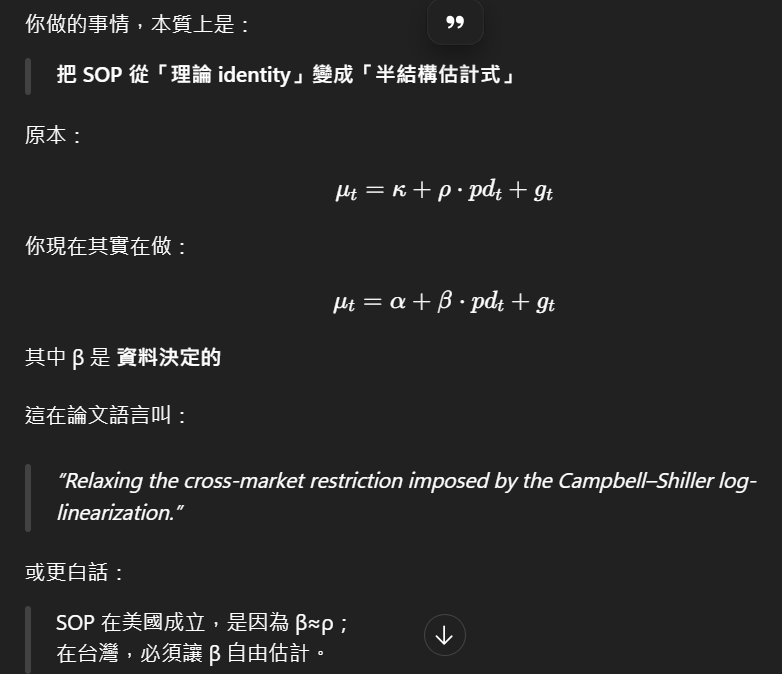

台灣市場中，股利不是定錨核心，很多報酬來自價差
價格大量反映非基本面因素 (台股相對美股不效率)


### 延伸研究